In [1]:
!nvidia-smi

Sat Jun 13 13:42:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch

print("CUDA Available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU: Tesla T4


In [6]:
#Dependecies
!pip install -q kaggle
!pip install -q timm
!pip install -q albumentations
!pip install -q opencv-python
!pip install -q scikit-learn
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 58.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [7]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sungjinwoo356326","key":"d6e5c04ad946f5b5f7118c1bba6a953d"}'}

In [8]:
!mkdir -p ~/.kaggle

!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/DermaVision"

os.makedirs(PROJECT_DIR, exist_ok=True)

print(PROJECT_DIR)

/content/drive/MyDrive/DermaVision


In [ ]:
import os

folders = [
    "raw_data",
    "processed_data",
    "models",
    "notebooks",
    "results",
    "reports",
    "src"
]

for f in folders:
    os.makedirs(f"{PROJECT_DIR}/{f}", exist_ok=True)

print("Folders created.")

Folders created.


In [9]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [1]:
!kaggle datasets download \
-d andrewmvd/isic-2019 \
-p "/content/ISICDATA"

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/isic-2019
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 9.10G/9.10G [03:53<00:00, 41.9MB/s]



In [2]:
!unzip -q \
"/content/ISICDATA/isic-2019.zip" \
-d "/content/ISICDATA"

In [3]:
import os

print(os.listdir("/content/ISICDATA")[:20])

print()

['isic-2019.zip', 'ISIC_2019_Training_Metadata.csv', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_GroundTruth.csv']



In [11]:
class_counts = isic_gt.iloc[:,1:].sum()

print(class_counts.sort_values(ascending=False))

NV      12875.0
MEL      4522.0
BCC      3323.0
BKL      2624.0
AK        867.0
SCC       628.0
VASC      253.0
DF        239.0
UNK         0.0
dtype: float64


In [13]:
len(duplicates)

10015

In [14]:
import pandas as pd

gt = pd.read_csv(
    "/content/drive/MyDrive/DermaVision/raw_data/ISIC2019/ISIC_2019_Training_GroundTruth.csv"
)

print(gt.isnull().sum().sum())

print(gt.shape)

print(gt.iloc[:,1:].sum(axis=1).value_counts())

0
(25331, 10)
1.0    25331
Name: count, dtype: int64


In [15]:
import pandas as pd
import numpy as np

gt_path = "/content/drive/MyDrive/DermaVision/raw_data/ISIC2019/ISIC_2019_Training_GroundTruth.csv"

gt = pd.read_csv(gt_path)

classes = ['AK','BCC','BKL','DF','MEL','NV','SCC','VASC']

gt['label'] = gt[classes].idxmax(axis=1)

master_df = pd.DataFrame({
    'image_id': gt['image'],
    'label': gt['label']
})

print(master_df.head())

print("\nShape:", master_df.shape)

       image_id label
0  ISIC_0000000    NV
1  ISIC_0000001    NV
2  ISIC_0000002   MEL
3  ISIC_0000003    NV
4  ISIC_0000004   MEL

Shape: (25331, 2)


In [16]:
print(master_df['label'].value_counts())

label
NV      12875
MEL      4522
BCC      3323
BKL      2624
AK        867
SCC       628
VASC      253
DF        239
Name: count, dtype: int64


In [17]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    master_df,
    test_size=0.30,
    stratify=master_df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=42
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 17731
Val: 3800
Test: 3800


In [18]:
import os

PROC_DIR = "/content/drive/MyDrive/DermaVision/processed_data"

os.makedirs(PROC_DIR, exist_ok=True)

In [19]:
train_df.to_csv(f"{PROC_DIR}/train.csv", index=False)
val_df.to_csv(f"{PROC_DIR}/val.csv", index=False)
test_df.to_csv(f"{PROC_DIR}/test.csv", index=False)

print("Saved successfully")

Saved successfully


In [20]:
import os

base = "/content/drive/MyDrive/DermaVision/raw_data/ISIC2019"

for item in os.listdir(base):
    print(item)

ISIC_2019_Training_GroundTruth.csv
ISIC_2019_Training_Metadata.csv
ISIC_2019_Training_Input


In [21]:
inner = "/content/drive/MyDrive/DermaVision/raw_data/ISIC2019/ISIC_2019_Training_Input"

print(os.listdir(inner)[:20])

['ISIC_2019_Training_Input']


In [22]:
IMG_DIR = "/content/drive/MyDrive/DermaVision/raw_data/ISIC2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input"

In [23]:
from PIL import Image
import os

IMG_DIR = "/content/drive/MyDrive/DermaVision/raw_data/ISIC2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input"

image_files = [
    f for f in os.listdir(IMG_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

widths = []
heights = []

for img_name in image_files[:100]:
    img = Image.open(os.path.join(IMG_DIR, img_name))
    widths.append(img.width)
    heights.append(img.height)

print("Images checked:", len(widths))
print("Min Width :", min(widths))
print("Max Width :", max(widths))
print("Min Height:", min(heights))
print("Max Height:", max(heights))

Images checked: 100
Min Width : 1024
Max Width : 1024
Min Height: 1024
Max Height: 1024


In [24]:
print("Total images:", len(image_files))

Total images: 25331


In [25]:
import pandas as pd
import os

IMG_DIR = "/content/ISICDATA/ISIC_2019_Training_Input"

classes = [
    "AK",
    "BCC",
    "BKL",
    "DF",
    "MEL",
    "NV",
    "SCC",
    "VASC"
]

label_map = {cls: idx for idx, cls in enumerate(classes)}

master_df["class_idx"] = master_df["label"].map(label_map)

master_df["image_path"] = master_df["image_id"].apply(
    lambda x: os.path.join(
        IMG_DIR,
        f"{x}.jpg"
    )
)

master_df.head()

,image_id,label,class_idx,image_path
0,ISIC_0000000,NV,5,/content/drive/MyDrive/DermaVision/raw_data/IS...
1,ISIC_0000001,NV,5,/content/drive/MyDrive/DermaVision/raw_data/IS...
2,ISIC_0000002,MEL,4,/content/drive/MyDrive/DermaVision/raw_data/IS...
3,ISIC_0000003,NV,5,/content/drive/MyDrive/DermaVision/raw_data/IS...
4,ISIC_0000004,MEL,4,/content/drive/MyDrive/DermaVision/raw_data/IS...


In [26]:
print(master_df.sample(5))

           image_id label  class_idx  \
12354  ISIC_0033757    NV          5   
9479   ISIC_0030882  VASC          7   
19187  ISIC_0063521   MEL          4   
24238  ISIC_0071538   MEL          4   
11309  ISIC_0032712    NV          5   

                                              image_path  
12354  /content/drive/MyDrive/DermaVision/raw_data/IS...  
9479   /content/drive/MyDrive/DermaVision/raw_data/IS...  
19187  /content/drive/MyDrive/DermaVision/raw_data/IS...  
24238  /content/drive/MyDrive/DermaVision/raw_data/IS...  
11309  /content/drive/MyDrive/DermaVision/raw_data/IS...  


In [27]:
missing = master_df[
    ~master_df["image_path"].apply(os.path.exists)
]

print("Missing images:", len(missing))

Missing images: 25331


In [28]:
import os

base = "/content/drive/MyDrive/DermaVision/raw_data/ISIC2019"

for root, dirs, files in os.walk(base):
    jpg_count = sum(1 for f in files if f.lower().endswith(".jpg"))
    if jpg_count > 0:
        print("\nFolder:", root)
        print("JPG Files:", jpg_count)
        print("Sample:", files[:5])


Folder: /content/drive/MyDrive/DermaVision/raw_data/ISIC2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input
JPG Files: 25331
Sample: ['ISIC_0071694.jpg', 'ISIC_0071712.jpg', 'ISIC_0071713.jpg', 'ISIC_0071691.jpg', 'ISIC_0071709.jpg']


In [29]:
IMG_DIR = "/content/drive/MyDrive/DermaVision/raw_data/ISIC2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input"

In [30]:
import os

IMG_DIR = "/content/drive/MyDrive/DermaVision/raw_data/ISIC2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input"

test_file = os.path.join(IMG_DIR, "ISIC_0000000.jpg")

print(os.path.exists(test_file))
print(test_file)

True
/content/drive/MyDrive/DermaVision/raw_data/ISIC2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input/ISIC_0000000.jpg


In [31]:
master_df["image_path"] = master_df["image_id"].apply(
    lambda x: os.path.join(IMG_DIR, f"{x}.jpg")
)

missing = master_df[
    ~master_df["image_path"].apply(os.path.exists)
]

print("Missing images:", len(missing))

Missing images: 0


In [32]:
MASTER_DIR = "/content/drive/MyDrive/DermaVision/processed_data"

master_df.to_csv(
    f"{MASTER_DIR}/master_dataset.csv",
    index=False
)

print("Master dataset saved.")

Master dataset saved.


**TRAINING PIPELINE SETUP**

In [4]:
!pip install -q timm albumentations opencv-python-headless torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 33.5 MB/s eta 0:00:00


In [60]:
import pandas as pd

master_df = pd.read_csv(
    "/content/drive/MyDrive/DermaVision/processed_data/master_dataset.csv"
)

print(master_df.head())
print(master_df.shape)

       image_id label  class_idx  \
0  ISIC_0000000    NV          5   
1  ISIC_0000001    NV          5   
2  ISIC_0000002   MEL          4   
3  ISIC_0000003    NV          5   
4  ISIC_0000004   MEL          4   

                                          image_path  
0  /content/drive/MyDrive/DermaVision/raw_data/IS...  
1  /content/drive/MyDrive/DermaVision/raw_data/IS...  
2  /content/drive/MyDrive/DermaVision/raw_data/IS...  
3  /content/drive/MyDrive/DermaVision/raw_data/IS...  
4  /content/drive/MyDrive/DermaVision/raw_data/IS...  
(25331, 4)


In [18]:
CLASSES = [
    "AK",
    "BCC",
    "BKL",
    "DF",
    "MEL",
    "NV",
    "SCC",
    "VASC"
]

label2idx = {c:i for i,c in enumerate(CLASSES)}
idx2label = {i:c for c,i in label2idx.items()}

print(label2idx)

{'AK': 0, 'BCC': 1, 'BKL': 2, 'DF': 3, 'MEL': 4, 'NV': 5, 'SCC': 6, 'VASC': 7}


In [62]:
train_df = pd.read_csv(
    "/content/drive/MyDrive/DermaVision/processed_data/train.csv"
)

val_df = pd.read_csv(
    "/content/drive/MyDrive/DermaVision/processed_data/val.csv"
)

test_df = pd.read_csv(
    "/content/drive/MyDrive/DermaVision/processed_data/test.csv"
)

print(len(train_df))
print(len(val_df))
print(len(test_df))

17731
3800
3800


In [164]:
!nvidia-smi

Sat Jun 13 14:26:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   76C    P0             34W /   70W |    2771MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
IMG_DIR = "/content/ISICDATA/ISIC_2019_Training_Input/ISIC_2019_Training_Input"

In [6]:
import os

IMG_DIR = "/content/ISICDATA/ISIC_2019_Training_Input/ISIC_2019_Training_Input"

print("Total Images:", len(os.listdir(IMG_DIR)))

sample = os.listdir(IMG_DIR)[0]
print("Sample:", sample)

Total Images: 25333
Sample: ISIC_0014061_downsampled.jpg


In [9]:
import pandas as pd

train_df = pd.read_csv(
    "/content/drive/MyDrive/DermaVision/processed_data/train.csv"
)

val_df = pd.read_csv(
    "/content/drive/MyDrive/DermaVision/processed_data/val.csv"
)

test_df = pd.read_csv(
    "/content/drive/MyDrive/DermaVision/processed_data/test.csv"
)

print(len(train_df))
print(len(val_df))
print(len(test_df))

17731
3800
3800


In [10]:
CLASSES = [
    "AK",
    "BCC",
    "BKL",
    "DF",
    "MEL",
    "NV",
    "SCC",
    "VASC"
]

label2idx = {c:i for i,c in enumerate(CLASSES)}

for df in [train_df, val_df, test_df]:

    df["class_idx"] = df["label"].map(label2idx)

print(label2idx)

{'AK': 0, 'BCC': 1, 'BKL': 2, 'DF': 3, 'MEL': 4, 'NV': 5, 'SCC': 6, 'VASC': 7}


In [11]:
for df in [train_df, val_df, test_df]:

    df["image_path"] = df["image_id"].apply(
        lambda x: f"{IMG_DIR}/{x}.jpg"
    )

print(train_df.head())

       image_id label  class_idx  \
0  ISIC_0026756    NV          5   
1  ISIC_0055875   BCC          1   
2  ISIC_0032535   MEL          4   
3  ISIC_0024758   BKL          2   
4  ISIC_0033089   MEL          4   

                                          image_path  
0  /content/ISICDATA/ISIC_2019_Training_Input/ISI...  
1  /content/ISICDATA/ISIC_2019_Training_Input/ISI...  
2  /content/ISICDATA/ISIC_2019_Training_Input/ISI...  
3  /content/ISICDATA/ISIC_2019_Training_Input/ISI...  
4  /content/ISICDATA/ISIC_2019_Training_Input/ISI...  


In [12]:
import os

print(
    os.path.exists(
        train_df.iloc[0]["image_path"]
    )
)

print(
    train_df.iloc[0]["image_path"]
)

True
/content/ISICDATA/ISIC_2019_Training_Input/ISIC_2019_Training_Input/ISIC_0026756.jpg


**Building Transforms**

In [13]:
!pip install -q timm
!pip install -q albumentations
!pip install -q opencv-python-headless

In [14]:
import cv2
import torch
import numpy as np

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import WeightedRandomSampler

import albumentations as A

from albumentations.pytorch import ToTensorV2

In [15]:
IMAGE_SIZE = 224

train_transform = A.Compose([

    A.Resize(IMAGE_SIZE, IMAGE_SIZE),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),

    A.Rotate(limit=25, p=0.5),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5
    ),

    A.Normalize(),
    ToTensorV2()

])

val_transform = A.Compose([

    A.Resize(IMAGE_SIZE, IMAGE_SIZE),

    A.Normalize(),

    ToTensorV2()

])

In [16]:
class SkinDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.df = dataframe.reset_index(drop=True)

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[idx]

        image = cv2.imread(
            row.image_path
        )

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        label = int(
            row.class_idx
        )

        if self.transform:

            image = self.transform(
                image=image
            )["image"]

        return image, label

In [17]:
train_dataset = SkinDataset(
    train_df,
    train_transform
)

val_dataset = SkinDataset(
    val_df,
    val_transform
)

test_dataset = SkinDataset(
    test_df,
    val_transform
)

print(len(train_dataset))

17731


In [18]:
class_sample_count = np.array(
    [
        len(
            train_df[
                train_df.label == c
            ]
        )
        for c in CLASSES
    ]
)

weights_per_class = (
    1.0 / class_sample_count
)

sample_weights = np.array(
    [
        weights_per_class[
            label2idx[l]
        ]
        for l in train_df.label
    ]
)

sample_weights = (
    torch.from_numpy(
        sample_weights
    ).double()
)

sampler = WeightedRandomSampler(
    sample_weights,
    len(sample_weights),
    replacement=True
)

In [28]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [20]:
import time

start = time.time()

images, labels = next(
    iter(train_loader)
)

print(images.shape)

print(
    "Time:",
    time.time() - start
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


torch.Size([16, 3, 224, 224])
Time: 2.208225965499878


In [21]:
import torch

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU: Tesla T4


In [22]:
images, labels = next(iter(train_loader))

print(images.shape)

torch.Size([16, 3, 224, 224])


In [24]:
import torch
import timm

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=8
)

model = model.to(DEVICE)

print(
    f"Parameters: {sum(p.numel() for p in model.parameters()):,}"
)

Device: cuda


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Parameters: 27,525,506


In [25]:
images = images.to(DEVICE)

with torch.no_grad():
    outputs = model(images)

print(outputs.shape)

torch.Size([16, 8])


In [26]:
print(torch.cuda.get_device_name(0))

Tesla T4


**TRAINING LOOP**

In [29]:
#Training Loop New Swin Model
import os
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score

# =====================================================
# LOSS
# =====================================================

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

# =====================================================
# OPTIMIZER
# =====================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-5,
    weight_decay=1e-4
)

# =====================================================
# TRAINING CONFIG
# =====================================================

EPOCHS = 15

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

scaler = torch.amp.GradScaler("cuda")

# =====================================================
# SAVE PATH
# =====================================================

SAVE_DIR = "/content/drive/MyDrive/DermaVision/models"

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

MODEL_PATH = os.path.join(
    SAVE_DIR,
    "swin_tiny_best.pth"
)

# =====================================================
# TRAIN FUNCTION
# =====================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    device
):

    model.train()

    running_loss = 0.0

    all_preds = []
    all_labels = []

    for images, labels in loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        preds = outputs.argmax(1)

        all_preds.extend(
            preds.detach().cpu().numpy()
        )

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

    epoch_loss = (
        running_loss / len(loader)
    )

    epoch_acc = accuracy_score(
        all_labels,
        all_preds
    )

    return epoch_loss, epoch_acc

# =====================================================
# VALIDATION FUNCTION
# =====================================================

@torch.no_grad()
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    all_preds = []
    all_labels = []

    for images, labels in loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        running_loss += loss.item()

        preds = outputs.argmax(1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

    epoch_loss = (
        running_loss / len(loader)
    )

    epoch_acc = accuracy_score(
        all_labels,
        all_preds
    )

    return epoch_loss, epoch_acc

# =====================================================
# TRAINING LOOP
# =====================================================

best_val_acc = 0.0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scaler,
        DEVICE
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            MODEL_PATH
        )

        print(
            f"✅ Best Model Saved "
            f"(Val Acc: {best_val_acc:.4f})"
        )

print("\nTraining Finished")
print(
    "Best Validation Accuracy:",
    best_val_acc
)

Epoch [1/15] | Train Loss: 1.0503 | Train Acc: 0.7309 | Val Loss: 1.0336 | Val Acc: 0.7247
✅ Best Model Saved (Val Acc: 0.7247)
Epoch [2/15] | Train Loss: 0.8347 | Train Acc: 0.8353 | Val Loss: 1.0052 | Val Acc: 0.7395
✅ Best Model Saved (Val Acc: 0.7395)
Epoch [3/15] | Train Loss: 0.7362 | Train Acc: 0.8795 | Val Loss: 0.9450 | Val Acc: 0.7779
✅ Best Model Saved (Val Acc: 0.7779)
Epoch [4/15] | Train Loss: 0.6845 | Train Acc: 0.9073 | Val Loss: 0.9986 | Val Acc: 0.7521
Epoch [5/15] | Train Loss: 0.6454 | Train Acc: 0.9250 | Val Loss: 0.9210 | Val Acc: 0.7837
✅ Best Model Saved (Val Acc: 0.7837)
Epoch [6/15] | Train Loss: 0.6185 | Train Acc: 0.9363 | Val Loss: 0.8838 | Val Acc: 0.8034
✅ Best Model Saved (Val Acc: 0.8034)
Epoch [7/15] | Train Loss: 0.5893 | Train Acc: 0.9503 | Val Loss: 0.8576 | Val Acc: 0.8247
✅ Best Model Saved (Val Acc: 0.8247)
Epoch [8/15] | Train Loss: 0.5729 | Train Acc: 0.9574 | Val Loss: 0.8777 | Val Acc: 0.8121
Epoch [9/15] | Train Loss: 0.5564 | Train Acc: 0.9

**Final Validation**

In [30]:
from sklearn.metrics import classification_report

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/DermaVision/models/swin_tiny_best.pth",
        map_location=DEVICE
    )
)

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        preds = outputs.argmax(1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=CLASSES
    )
)

              precision    recall  f1-score   support

          AK       0.81      0.71      0.76       130
         BCC       0.87      0.94      0.90       498
         BKL       0.81      0.81      0.81       394
          DF       0.97      0.78      0.86        36
         MEL       0.81      0.78      0.79       678
          NV       0.91      0.92      0.91      1932
         SCC       0.78      0.70      0.74        94
        VASC       0.95      0.95      0.95        38

    accuracy                           0.87      3800
   macro avg       0.86      0.82      0.84      3800
weighted avg       0.87      0.87      0.87      3800



**EVALUATION AND SAVING MODELS**

In [31]:
MODEL_PATH = (
    "/content/drive/MyDrive/DermaVision/models/"
    "swin_tiny_final_87_13.pth"
)

torch.save(
    model.state_dict(),
    MODEL_PATH
)

print("Model Saved:", MODEL_PATH)

Model Saved: /content/drive/MyDrive/DermaVision/models/swin_tiny_final_87_13.pth


In [33]:
import os

folders = [
    "/content/drive/MyDrive/DermaVision/artifacts",
    "/content/drive/MyDrive/DermaVision/results/plots",
    "/content/drive/MyDrive/DermaVision/results/reports",
    "/content/drive/MyDrive/DermaVision/results/confusion_matrix"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


In [34]:
import json

CLASSES = [
    "AK",
    "BCC",
    "BKL",
    "DF",
    "MEL",
    "NV",
    "SCC",
    "VASC"
]

label_mapping = {
    str(i): cls
    for i, cls in enumerate(CLASSES)
}

with open(
    "/content/drive/MyDrive/DermaVision/artifacts/label_mapping.json",
    "w"
) as f:
    json.dump(label_mapping, f, indent=4)

print("label_mapping.json saved")

label_mapping.json saved


In [35]:
from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_preds,
    target_names=CLASSES
)

print(report)

with open(
    "/content/drive/MyDrive/DermaVision/results/reports/classification_report.txt",
    "w"
) as f:

    f.write(report)

print("Report Saved")

              precision    recall  f1-score   support

          AK       0.81      0.71      0.76       130
         BCC       0.87      0.94      0.90       498
         BKL       0.81      0.81      0.81       394
          DF       0.97      0.78      0.86        36
         MEL       0.81      0.78      0.79       678
          NV       0.91      0.92      0.91      1932
         SCC       0.78      0.70      0.74        94
        VASC       0.95      0.95      0.95        38

    accuracy                           0.87      3800
   macro avg       0.86      0.82      0.84      3800
weighted avg       0.87      0.87      0.87      3800

Report Saved


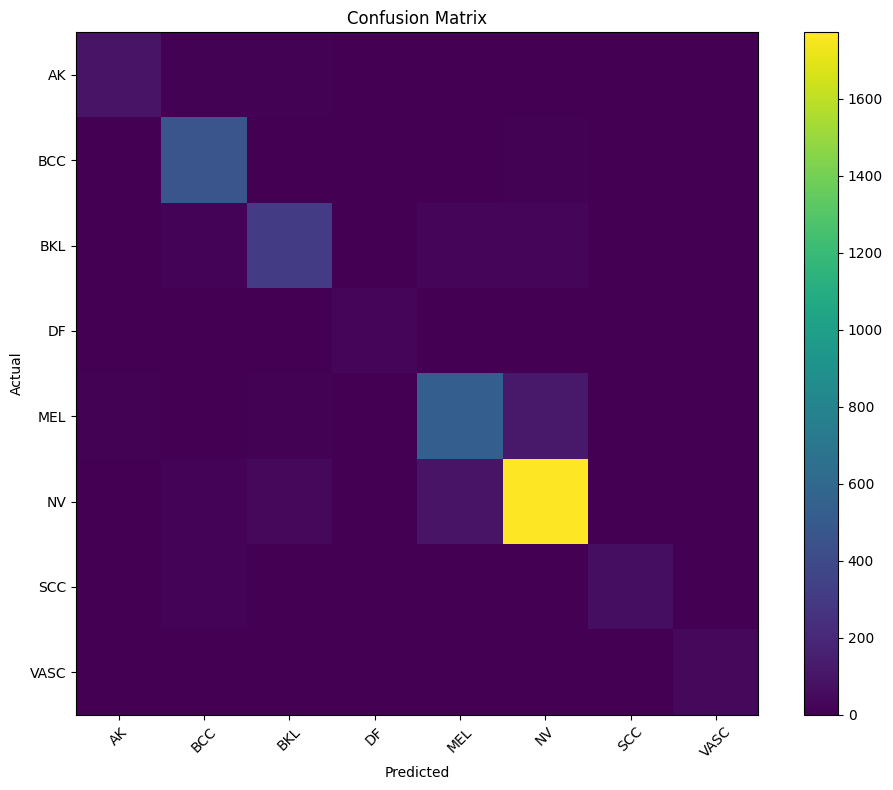

Saved: /content/drive/MyDrive/DermaVision/results/confusion_matrix/confusion_matrix.png


In [36]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(10,8))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    np.arange(len(CLASSES)),
    CLASSES,
    rotation=45
)

plt.yticks(
    np.arange(len(CLASSES)),
    CLASSES
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.tight_layout()

save_path = (
    "/content/drive/MyDrive/DermaVision/"
    "results/confusion_matrix/confusion_matrix.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", save_path)

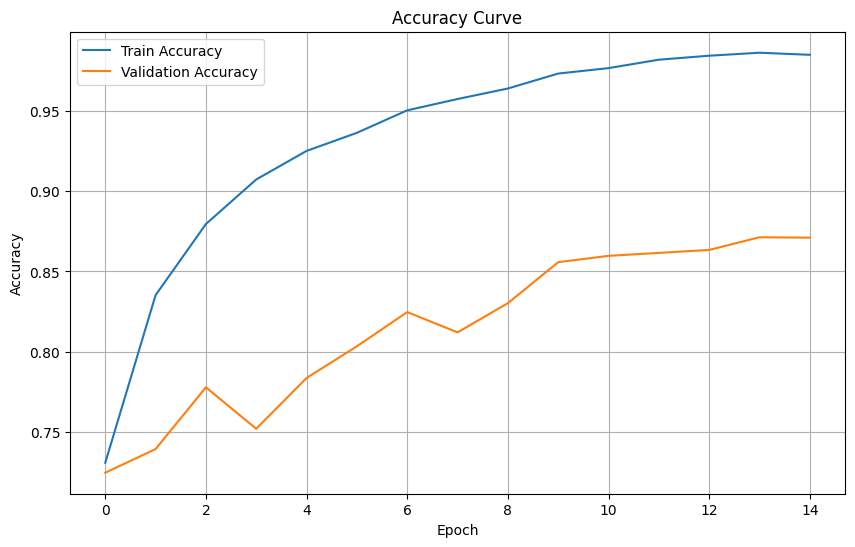

Saved: /content/drive/MyDrive/DermaVision/results/plots/accuracy_curve.png


In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    history["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    history["val_acc"],
    label="Validation Accuracy"
)

plt.legend()

plt.title("Accuracy Curve")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.grid(True)

save_path = (
    "/content/drive/MyDrive/DermaVision/"
    "results/plots/accuracy_curve.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", save_path)

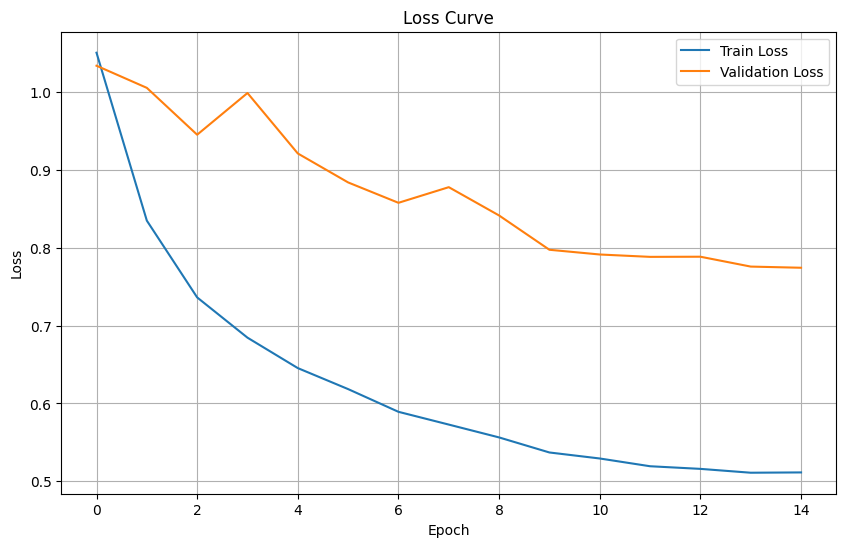

Saved: /content/drive/MyDrive/DermaVision/results/plots/loss_curve.png


In [38]:
plt.figure(figsize=(10,6))

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.legend()

plt.title("Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

save_path = (
    "/content/drive/MyDrive/DermaVision/"
    "results/plots/loss_curve.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", save_path)

In [39]:
import json

metrics = {
    "model": "Swin Transformer Tiny",
    "validation_accuracy": 0.8713157894736843,
    "num_classes": 8,
    "dataset": "ISIC2019",
    "image_size": 224
}

with open(
    "/content/drive/MyDrive/DermaVision/artifacts/final_metrics.json",
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )

print("Metrics Saved")

Metrics Saved


In [40]:
import timm
import torch

CLASSES = [
    "AK",
    "BCC",
    "BKL",
    "DF",
    "MEL",
    "NV",
    "SCC",
    "VASC"
]

model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=False,
    num_classes=8
)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/DermaVision/models/swin_tiny_final_87_13.pth",
        map_location="cpu"
    )
)

model.eval()

SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
            (drop1): 